Entrenando LDA (Linear Discriminant Analysis)...
Entrenando QDA (Quadratic Discriminant Analysis)...

Accuracy Global - LDA (Lineal): 0.6723
Accuracy Global - QDA (Cuadrático): 0.5450


c:\Users\TieriTina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


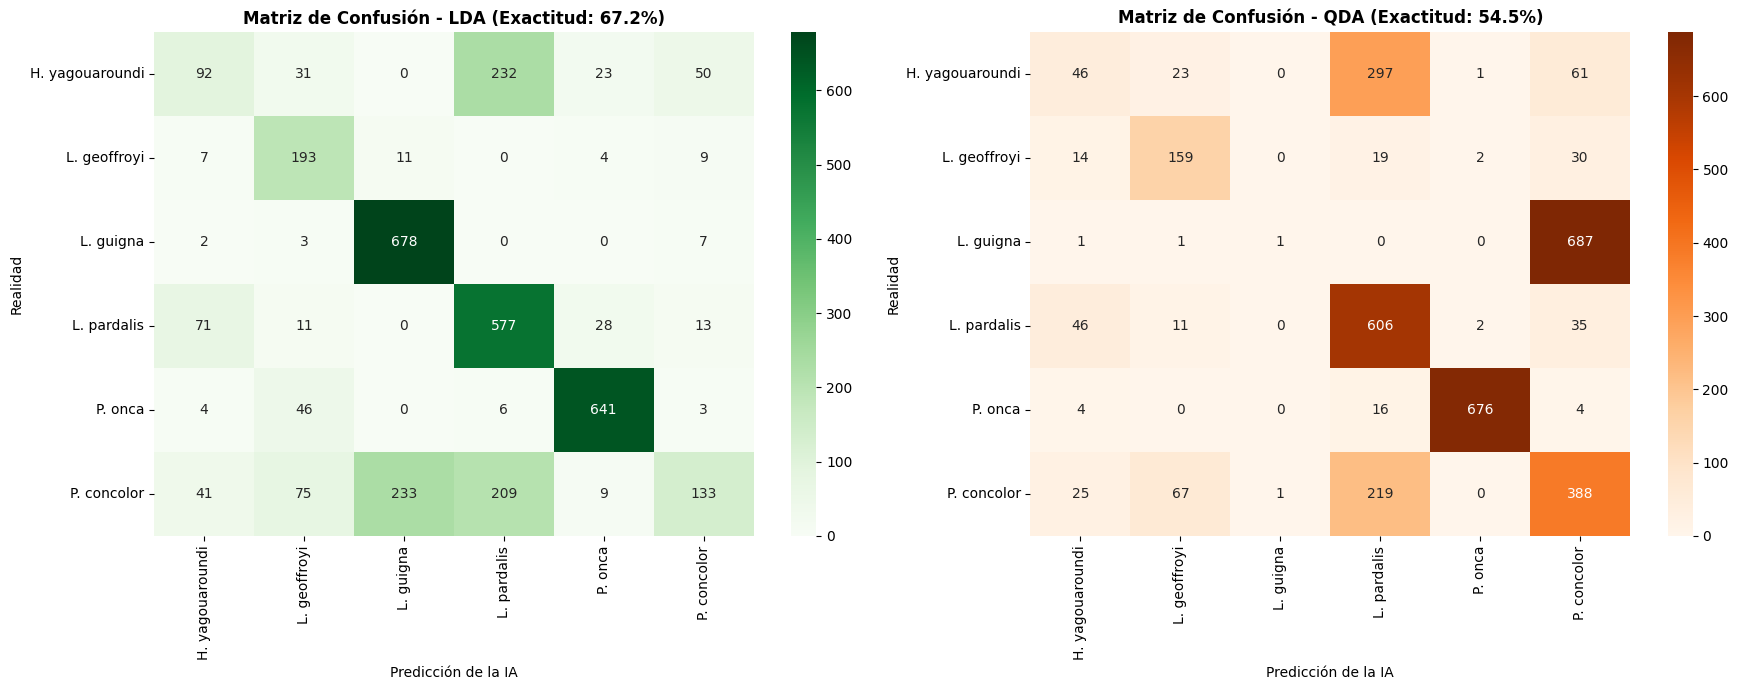

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Cargar las matrices estandarizadas 
X_train_scaled = pd.read_csv('../Datos/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../Datos/X_test_scaled.csv')
y_train = pd.read_csv('../Datos/y_train.csv').values.ravel()
y_test = pd.read_csv('../Datos/y_test.csv').values.ravel()

# Lista de nombres de las especies para las métricas
especies_nombres = ['H. yagouaroundi', 'L. geoffroyi', 'L. guigna', 'L. pardalis', 'P. onca', 'P. concolor']

# =====================================================================
# ENTRENAMIENTO DE MODELOS DISCRIMINANTES
# =====================================================================
print("Entrenando LDA (Linear Discriminant Analysis)...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)

print("Entrenando QDA (Quadratic Discriminant Analysis)...")
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred_qda = qda.predict(X_test_scaled)

# =====================================================================
# EVALUACIÓN Y MATRICES DE CONFUSIÓN
# =====================================================================
acc_lda = accuracy_score(y_test, y_pred_lda)
acc_qda = accuracy_score(y_test, y_pred_qda)

print("\n" + "="*40)
print(f"Accuracy Global - LDA (Lineal): {acc_lda:.4f}")
print(f"Accuracy Global - QDA (Cuadrático): {acc_qda:.4f}")
print("="*40)

# Graficar las nuevas matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(y_test, y_pred_lda), annot=True, fmt="d", cmap="Greens", xticklabels=especies_nombres, yticklabels=especies_nombres, ax=axes[0])
axes[0].set_title(f'Matriz de Confusión - LDA (Exactitud: {acc_lda*100:.1f}%)', fontweight='bold')
axes[0].set_xlabel('Predicción de la IA')
axes[0].set_ylabel('Realidad')

sns.heatmap(confusion_matrix(y_test, y_pred_qda), annot=True, fmt="d", cmap="Oranges", xticklabels=especies_nombres, yticklabels=especies_nombres, ax=axes[1])
axes[1].set_title(f'Matriz de Confusión - QDA (Exactitud: {acc_qda*100:.1f}%)', fontweight='bold')
axes[1].set_xlabel('Predicción de la IA')
axes[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()


### Análisis Comparativo de Fronteras Discriminantes y Trade-off Bias-Varianza

Los resultados obtenidos exponen de forma empírica cómo los supuestos matemáticos de los clasificadores impactan directamente en el modelado ecológico:

1.  **El Colapso de QDA (54.5%) ante la Falta de Flexibilidad en Datos Ruidosos:** 
    A diferencia de LDA, el Análisis Discriminante Cuadrático (QDA) estima una matriz de covarianza $\Sigma_k$ independiente para cada una de las 6 especies. Al otorgarle tanta libertad geométrica (fronteras cuadráticas/curvas), el modelo sufrió de una **alta varianza (overfitting)** en variables con mucho solapamiento como las coordenadas espaciales. 
    *El error crítico de la Güiña (_L. guigna_):* QDA colapsó por completo clasificando casi todas las güiñas reales (687 registros) como Pumas (_P. concolor_). Esto ocurre porque la frontera cuadrática se deformó erróneamente debido al ruido geográfico de la región chileno-patagónica.

2.  **La Estabilidad de LDA (67.2%) mediante la Homocedasticidad:**
    Al forzar a todas las clases a compartir una única matriz de covarianza común ($\Sigma$), LDA traza hiperplanos lineales más rígidos. Aunque sufre de un **mayor sesgo (bias)**, esta rigidez geométrica actuó como un regularizador natural que previno los errores groseros de QDA, manteniendo a la Güiña (*L. guigna*) y al Yaguareté (*P. onca*) con clasificaciones altamente precisas en la diagonal principal.

3.  **La persistencia del "Enigma del Puma" (_P. concolor_):**
    Ninguno de los dos enfoques logra resolver el comportamiento del Puma. Mientras LDA lo subclasifica dispersándolo entre la Güiña y el Ocelote, QDA genera un polo de atracción artificial donde absorbe erróneamente a otras especies. Esto demuestra que las distribuciones de hábitats de felinos generalistas no cumplen con el supuesto de normalidad multivariada estricta que exigen estos dos métodos de la escuela clásica.
